In [46]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

TEXTURE_FEATURES_3D = [
    # GLCM features
    "3GLCM_ACOR", "3GLCM_ASM", "3GLCM_CLUPROM", "3GLCM_CLUSHADE", "3GLCM_CLUTEND",
    "3GLCM_CONTRAST", "3GLCM_CORRELATION", "3GLCM_DIFAVE", "3GLCM_DIFENTRO", "3GLCM_DIFVAR",
    "3GLCM_DIS", "3GLCM_ENERGY", "3GLCM_ENTROPY", "3GLCM_HOM1", "3GLCM_HOM2",
    "3GLCM_ID", "3GLCM_IDN", "3GLCM_IDM", "3GLCM_IDMN", "3GLCM_INFOMEAS1", "3GLCM_INFOMEAS2",
    "3GLCM_IV", "3GLCM_JAVE", "3GLCM_JE", "3GLCM_JMAX", "3GLCM_JVAR",
    "3GLCM_SUMAVERAGE", "3GLCM_SUMENTROPY", "3GLCM_SUMVARIANCE", "3GLCM_VARIANCE",
    "3GLCM_ASM_AVE", "3GLCM_ACOR_AVE", "3GLCM_CLUPROM_AVE", "3GLCM_CLUSHADE_AVE",
    "3GLCM_CLUTEND_AVE", "3GLCM_CONTRAST_AVE", "3GLCM_CORRELATION_AVE",
    "3GLCM_DIFAVE_AVE", "3GLCM_DIFENTRO_AVE", "3GLCM_DIFVAR_AVE", "3GLCM_DIS_AVE",
    "3GLCM_ENERGY_AVE", "3GLCM_ENTROPY_AVE", "3GLCM_HOM1_AVE", "3GLCM_ID_AVE",
    "3GLCM_IDN_AVE", "3GLCM_IDM_AVE", "3GLCM_IDMN_AVE", "3GLCM_IV_AVE",
    "3GLCM_JAVE_AVE", "3GLCM_JE_AVE", "3GLCM_INFOMEAS1_AVE", "3GLCM_INFOMEAS2_AVE",
    "3GLCM_VARIANCE_AVE", "3GLCM_JMAX_AVE", "3GLCM_JVAR_AVE",
    "3GLCM_SUMAVERAGE_AVE", "3GLCM_SUMENTROPY_AVE", "3GLCM_SUMVARIANCE_AVE",

    # GLRLM features
    "3GLRLM_SRE", "3GLRLM_LRE", "3GLRLM_GLN", "3GLRLM_GLNN", "3GLRLM_RLN", "3GLRLM_RLNN",
    "3GLRLM_RP", "3GLRLM_GLV", "3GLRLM_RV", "3GLRLM_RE", "3GLRLM_LGLRE", "3GLRLM_HGLRE",
    "3GLRLM_SRLGLE", "3GLRLM_SRHGLE", "3GLRLM_LRLGLE", "3GLRLM_LRHGLE",
    "3GLRLM_SRE_AVE", "3GLRLM_LRE_AVE", "3GLRLM_GLN_AVE", "3GLRLM_GLNN_AVE",
    "3GLRLM_RLN_AVE", "3GLRLM_RLNN_AVE", "3GLRLM_RP_AVE", "3GLRLM_GLV_AVE",
    "3GLRLM_RV_AVE", "3GLRLM_RE_AVE", "3GLRLM_LGLRE_AVE", "3GLRLM_HGLRE_AVE",
    "3GLRLM_SRLGLE_AVE", "3GLRLM_SRHGLE_AVE", "3GLRLM_LRLGLE_AVE", "3GLRLM_LRHGLE_AVE",

    # GLSZM features
    "GLSZM_SAE", "GLSZM_LAE", "GLSZM_GLN", "GLSZM_GLNN", "GLSZM_SZN", "GLSZM_SZNN",
    "GLSZM_ZP", "GLSZM_GLV", "GLSZM_ZV", "GLSZM_ZE", "GLSZM_LGLZE", "GLSZM_HGLZE",
    "GLSZM_SALGLE", "GLSZM_SAHGLE", "GLSZM_LALGLE", "GLSZM_LAHGLE",

    # GLDM features
    "3GLDM_SDE", "3GLDM_LDE", "3GLDM_GLN", "3GLDM_DN", "3GLDM_DNN", "3GLDM_GLV",
    "3GLDM_DV", "3GLDM_DE", "3GLDM_LGLE", "3GLDM_HGLE", "3GLDM_SDLGLE", "3GLDM_SDHGLE",
    "3GLDM_LDLGLE", "3GLDM_LDHGLE",

    # GLDZM features
    "3GLDZM_SDE", "3GLDZM_LDE", "3GLDZM_LGLZE", "3GLDZM_HGLZE", "3GLDZM_SDLGLE",
    "3GLDZM_SDHGLE", "3GLDZM_LDLGLE", "3GLDZM_LDHGLE", "3GLDZM_GLNU", "3GLDZM_GLNUN",
    "3GLDZM_ZDNU", "3GLDZM_ZDNUN", "3GLDZM_ZP", "3GLDZM_GLM", "3GLDZM_GLV",
    "3GLDZM_ZDM", "3GLDZM_ZDV", "3GLDZM_ZDE",

    # NGLDM features
    "3NGLDM_LDE", "3NGLDM_HDE", "3NGLDM_LGLCE", "3NGLDM_HGLCE", "3NGLDM_LDLGLE",
    "3NGLDM_LDHGLE", "3NGLDM_HDLGLE", "3NGLDM_HDHGLE", "3NGLDM_GLNU", "3NGLDM_GLNUN",
    "3NGLDM_DCNU", "3NGLDM_DCNUN", "3NGLDM_DCP", "3NGLDM_GLM", "3NGLDM_GLV",
    "3NGLDM_DCM", "3NGLDM_DCV", "3NGLDM_DCENT", "3NGLDM_DCENE",

    # NGTDM features
    "3NGTDM_COARSENESS", "3NGTDM_CONTRAST", "3NGTDM_BUSYNESS", "3NGTDM_COMPLEXITY",
    "3NGTDM_STRENGTH",
]

In [47]:

def read_features(features_dir: str) -> pd.DataFrame:
    """Read features from a directory.
    
    Args:
        features_dir: Directory containing features
        
    Returns:
        DataFrame containing all features
    """
    features = []
    for file in os.listdir(features_dir):
        df = pd.read_csv(os.path.join(features_dir, file))
        features.append(df)
    return pd.concat(features, ignore_index=True)

In [48]:
original_features_dir = "../../datasets/Craig_scans/features" 
normalized_features_dir = "../../datasets/Craig_scans/normalized_features"

original_features = read_features(original_features_dir)
normalized_features = read_features(normalized_features_dir)

print(original_features.head())
print(normalized_features.head())



               intensity_image                   mask_image  ROI_label  \
0  human_brain_20130613.nii.gz  human_brain_20130613.nii.gz       50.0   
1  human_brain_20100513.nii.gz  human_brain_20100513.nii.gz       50.0   
2  human_brain_20100304.nii.gz  human_brain_20100304.nii.gz       50.0   
3  human_brain_20130403.nii.gz  human_brain_20130403.nii.gz       50.0   
4  human_brain_20121108.nii.gz  human_brain_20121108.nii.gz       50.0   

       3COV  3COVERED_IMAGE_INTENSITY_RANGE       3ENERGY  3ENTROPY  \
0  0.589830                             1.0  1.990064e+12  2.956464   
1  0.584896                             1.0  1.957909e+12  2.692284   
2  0.571353                             1.0  1.997573e+12  2.882276   
3  0.586386                             1.0  1.927582e+12  2.893618   
4  0.586373                             1.0  1.969741e+12  3.016116   

   3EXCESS_KURTOSIS  3HYPERFLATNESS  3HYPERSKEWNESS  ...  3GLRLM_RP_AVE  \
0         -1.024066        8.634829        1.569215  

In [49]:
def select_features(features: pd.DataFrame, feature_list: list) -> pd.DataFrame:
    """Select features from a DataFrame.
    
    Args:
        features: DataFrame containing features
        feature_list: List of feature names to select
        
    Returns:
        DataFrame containing selected features
    """ 
    return features[feature_list]


original_features = select_features(original_features, TEXTURE_FEATURES_3D)
normalized_features = select_features(normalized_features, TEXTURE_FEATURES_3D)

print(original_features.head())
print(normalized_features.head())

   3GLCM_ACOR  3GLCM_ASM  3GLCM_CLUPROM  3GLCM_CLUSHADE  3GLCM_CLUTEND  \
0   75.710878   0.258643   78805.192562     2333.716202     167.960499   
1   53.089421   0.263062   36646.125332     1319.314532     114.389434   
2   68.805723   0.271242   63612.891527     1995.486121     152.161456   
3   70.217960   0.260062   67179.461321     2075.997070     155.027794   
4   85.119727   0.241440   92143.316816     2576.417086     186.127598   

   3GLCM_CONTRAST  3GLCM_CORRELATION  3GLCM_DIFAVE  3GLCM_DIFENTRO  \
0        2.195587           0.974193      0.703800        1.637944   
1        1.460939           0.974779      0.569792        1.468993   
2        1.795864           0.976671      0.628210        1.543095   
3        2.122633           0.972986      0.691689        1.623726   
4        2.409198           0.974443      0.752394        1.697478   

   3GLCM_DIFVAR  ...  3NGLDM_GLV  3NGLDM_DCM  3NGLDM_DCV  3NGLDM_DCENT  \
0      1.700252  ...   43.012150   15.141583   89.816715    

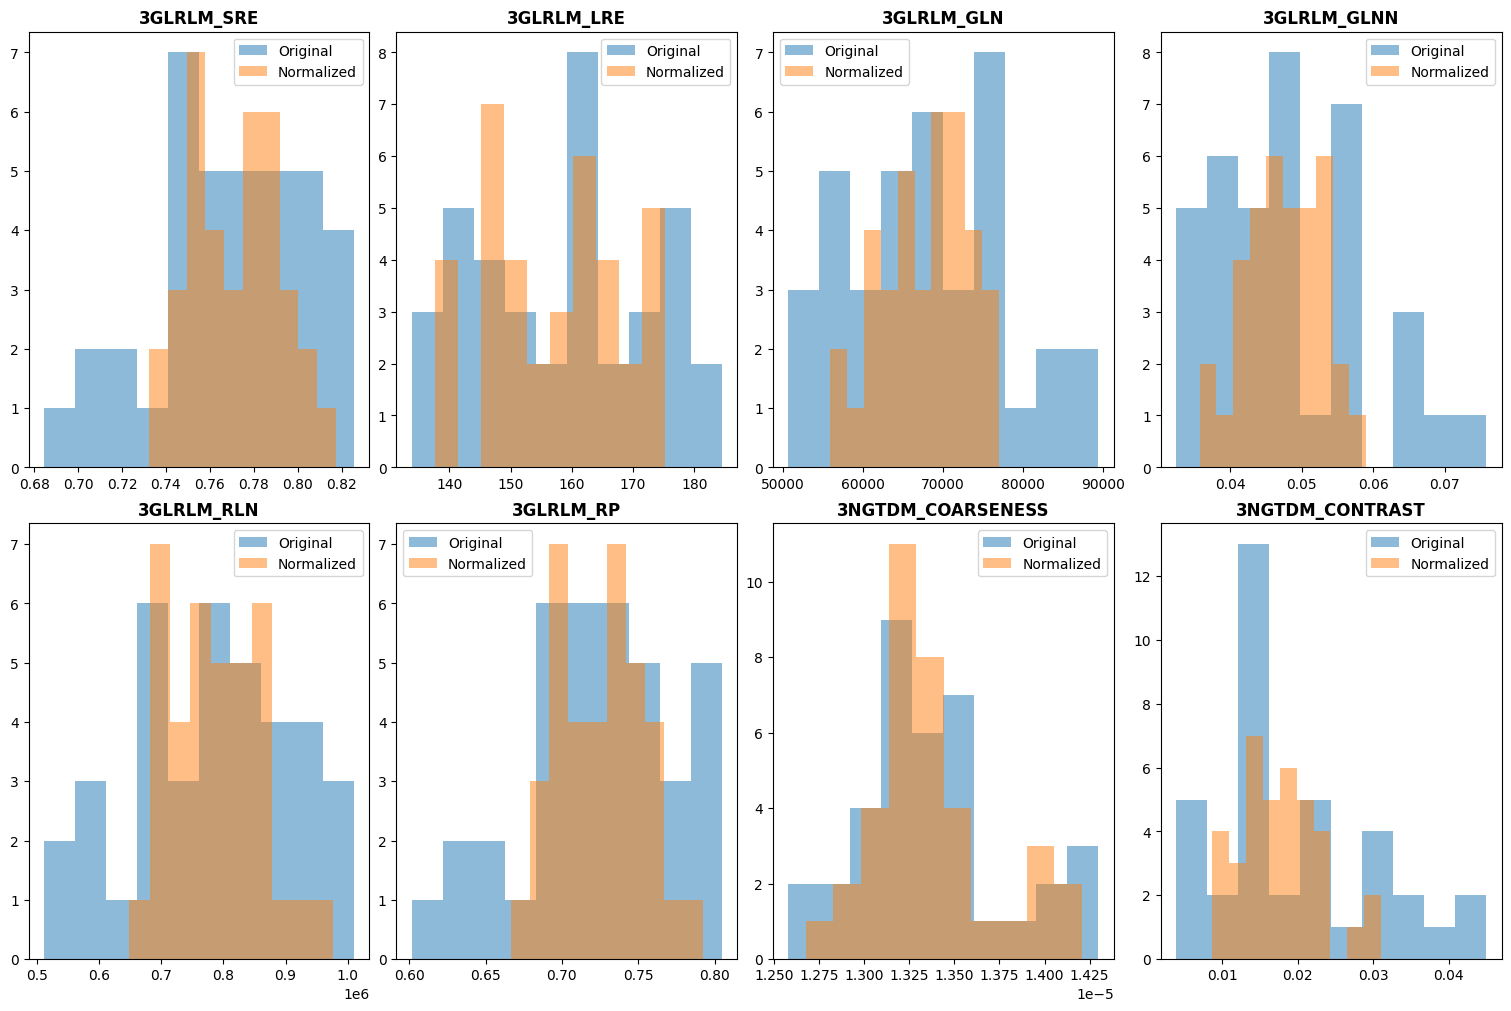

In [53]:
import matplotlib.pyplot as plt
num_bins = 10

filter_threshold = 100
fig, axs = plt.subplots(2, 4, figsize=(15, 10), constrained_layout=True)
cnt = 0 
sample_features = ["3GLRLM_SRE", "3GLRLM_LRE", "3GLRLM_GLN", "3GLRLM_GLNN", "3GLRLM_RLN", "3GLRLM_RP", "3NGTDM_COARSENESS", "3NGTDM_CONTRAST"]
for feature in sample_features:
    # print(f"Shape: {data.shape}, Values > {filter_threshold}: {len(filtered_data)}")

    axs[cnt//4, cnt%4].hist(original_features[feature],  bins=num_bins, alpha=0.5, label='Original')
    axs[cnt//4, cnt%4].hist(normalized_features[feature], bins=num_bins, alpha=0.5, label='Normalized')
    axs[cnt//4, cnt%4].set_title(feature, fontsize=12, fontweight='bold')
    # axs[cnt//3, cnt%3].set_xlabel('Signal Intensity')
    # axs[cnt//3, cnt%3].set_ylabel('Frequency')
    axs[cnt//4, cnt%4].legend()
    cnt += 1

# plt.legend()
plt.savefig("3D_texture_features_hist.png")
plt.show()

In [33]:
# Calculate significance for a single feature
def f_test_variance(feature_name, original_df, normalized_df, alpha=0.05) -> bool:
    var_original = np.var(original_df[feature_name], ddof=1)
    var_normalized = np.var(normalized_df[feature_name], ddof=1)
    
    f_stat = var_original / var_normalized
    n1, n2 = len(original_df), len(normalized_df)
    dfn, dfd = n1 - 1, n2 - 1
    # Calculate p-value for two-tailed F-test
    p_value = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))
    
    # print(f"Feature: {feature_name}")
    # print(f"Original variance: {var_original:.6f}")
    # print(f"Normalized variance: {var_normalized:.6f}")
    # print(f"F-statistic: {f_stat:.6f}")
    # print(f"p-value: {p_value:.6f}")
    # print("Interpretation:", end=" ")
    if p_value < alpha:
        if f_stat > 1:
            print("Original has significantly higher variance")
        else:
            print("Normalized has significantly higher variance")
    else:
        print("No significant difference in variances")

        return True
    print("-" * 50)
    return False


# Example usage for first few features
cnt = 0
for feature in TEXTURE_FEATURES_3D:
    if f_test_variance(feature, original_features, normalized_features):
        cnt += 1

print(f"Number of features with a significant difference in variance: {cnt}")

Original has significantly higher variance
--------------------------------------------------
No significant difference in variances
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
Original has significantly higher variance
--------------------------------------------------
No significant differ

/var/folders/1_/hbvlzgk167j9cnkp3c_fg7w05_1gfg/T/ipykernel_54703/4025558235.py:6: RuntimeWarning: invalid value encountered in scalar divide
  f_stat = var_original / var_normalized


In [31]:
def compare_features_wilcoxon(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                              feature_list: list[str], alpha: float = 0.05) -> pd.DataFrame:
    """Perform Wilcoxon signed-rank test to compare original and normalized features."""
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
            # Perform Wilcoxon test
            stat, p_value = stats.wilcoxon(original_df[feature], 
                                         normalized_df[feature],
                                         alternative='two-sided')
            
            # Calculate effect size
            n = len(original_df[feature])
            z_score = stats.norm.ppf(p_value / 2)
            
            # r < 0.1: Negligible effect
            # 0.1 ≤ r < 0.3: Small effect
            # 0.3 ≤ r < 0.5: Medium effect
            # r ≥ 0.5: Large effect
            effect_size = abs(z_score) / np.sqrt(n)
            
            # Determine direction
            mean_diff = np.mean(original_df[feature] - normalized_df[feature])
            direction = "higher" if mean_diff > 0 else "lower"
            
            results.append({
                'feature_name': feature,
                'statistic': stat,
                'p_value': p_value,
                'significant': p_value < alpha,
                'effect_size': effect_size,
                'original_vs_normalized': f"Original {direction} than normalized"
            })
    
    return pd.DataFrame(results).sort_values('p_value')

# Run the comparison
wilcoxon_results = compare_features_wilcoxon(original_features, normalized_features, 
                                           TEXTURE_FEATURES_3D)

# Show results
print("\nFeatures with significant differences (p < 0.05):")
significant = wilcoxon_results[wilcoxon_results['significant']]
print(significant[['feature_name', 'p_value', 'effect_size', 'original_vs_normalized']].head())


Features with significant differences (p < 0.05):
     feature_name   p_value  effect_size          original_vs_normalized
129   3GLDZM_GLNU  0.000060     0.659472  Original lower than normalized
156  3NGLDM_DCENT  0.016591     0.393842  Original lower than normalized
106  GLSZM_LAHGLE  0.040694     0.336464  Original lower than normalized


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [45]:
def calculate_kl_divergence(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                           feature_list: list[str], n_bins: int = 10) -> pd.DataFrame:
    """Calculate KL divergence between original and normalized features."""
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
          # Find common range for bins
            min_val = min(original_df[feature].min(), normalized_df[feature].min())
            max_val = max(original_df[feature].max(), normalized_df[feature].max())
            
            # Create common bins
            bins = np.linspace(min_val, max_val, n_bins + 1)
            
            # Use same bins for both histograms
            hist_orig, _ = np.histogram(original_df[feature], bins=bins, density=True)
            hist_norm, _ = np.histogram(normalized_df[feature], bins=bins, density=True)
            
            # Add small constant to avoid division by zero
            epsilon = 1e-10
            hist_orig = hist_orig + epsilon
            hist_norm = hist_norm + epsilon
            
            # Normalize
            hist_orig = hist_orig / hist_orig.sum()
            hist_norm = hist_norm / hist_norm.sum()
            
            # Calculate KL divergence
            kl_div = np.sum(hist_orig * np.log(hist_orig / hist_norm))
            
            results.append({
                'feature_name': feature,
                'kl_divergence': kl_div
            })
    
    return pd.DataFrame(results).sort_values('kl_divergence', ascending=False)

# Run the analysis
kl_results = calculate_kl_divergence(original_features, normalized_features, TEXTURE_FEATURES_3D)

# Show top 10 features with highest distribution differences
print("\nTop 10 features with highest KL divergence:")
print(kl_results[['feature_name', 'kl_divergence']].  head(10))


Top 10 features with highest KL divergence:
           feature_name  kl_divergence
47       3GLCM_IDMN_AVE       8.673958
114            3GLDM_DE       7.408526
21             3GLCM_IV       7.109871
159     3NGTDM_CONTRAST       6.911894
152          3NGLDM_GLM       6.770687
18           3GLCM_IDMN       6.486650
39     3GLCM_DIFVAR_AVE       6.321976
35   3GLCM_CONTRAST_AVE       6.300684
19      3GLCM_INFOMEAS1       6.076019
16            3GLCM_IDN       6.017537


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [44]:
def perform_anova_test(original_df: pd.DataFrame, normalized_df: pd.DataFrame, 
                      feature_list: list[str], alpha: float = 0.05) -> pd.DataFrame:
    """Perform one-way ANOVA test between original and normalized features.
    """
    results = []
    
    for feature in feature_list:
        if feature in original_df.columns and feature in normalized_df.columns:
            # Calculate basic statistics
            orig_mean = np.mean(original_df[feature])
            norm_mean = np.mean(normalized_df[feature])
            orig_var = np.var(original_df[feature], ddof=1)
            norm_var = np.var(normalized_df[feature], ddof=1)
            
            # Perform one-way ANOVA
            f_stat, p_value = stats.f_oneway(original_df[feature], 
                                           normalized_df[feature])
            
            # Calculate effect size (eta-squared)
            # η² = SSbetween / SStotal
            groups = [original_df[feature], normalized_df[feature]]
            grand_mean = np.mean([orig_mean, norm_mean])
            ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
            ss_total = sum((x - grand_mean)**2 for g in groups for x in g)
            eta_squared = ss_between / ss_total if ss_total != 0 else 0
            
            # The effect size thresholds (0.01, 0.06, 0.14) for eta-squared (η²)
            #  come from established statistical guidelines by Cohen (1988) and later researchers.
            if eta_squared < 0.01:
                effect_size_interp = "negligible"
            elif eta_squared < 0.06:
                effect_size_interp = "small"
            elif eta_squared < 0.14:
                effect_size_interp = "medium"
            else:
                effect_size_interp = "large"
            
            results.append({
                'feature_name': feature,
                'original_mean': orig_mean,
                'normalized_mean': norm_mean,
                'original_variance': orig_var,
                'normalized_variance': norm_var,
                'f_statistic': f_stat,
                'p_value': p_value,
                'significant': p_value < alpha,
                'eta_squared': eta_squared,
                'effect_size': effect_size_interp
            })
    
    results_df = pd.DataFrame(results)
    
    # Print summary
    print("ANOVA Test Results Summary:")
    print(f"Total features tested: {len(results_df)}")
    print(f"Features with significant differences: {sum(results_df['significant'])}")
    print("\nEffect size distribution:")
    print(results_df['effect_size'].value_counts())
    
    # Visualization of significant differences
    significant_results = results_df[results_df['significant']].sort_values('p_value')
    
 
    
    return results_df.sort_values('p_value')

# Run ANOVA analysis
anova_results = perform_anova_test(original_features, normalized_features, TEXTURE_FEATURES_3D)

# Show detailed results for top 5 most significant differences
significant = anova_results[anova_results['significant']]
print(significant[['feature_name', 'p_value', 'effect_size', 'original_mean', 'normalized_mean']].head())

ANOVA Test Results Summary:
Total features tested: 163
Features with significant differences: 0

Effect size distribution:
effect_size
negligible    153
small          10
Name: count, dtype: int64
Empty DataFrame
Columns: [feature_name, p_value, effect_size, original_mean, normalized_mean]
Index: []


/Users/donyapourn2/Desktop/projects/clinical-imaging-tools/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
